## **Setup**

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]  # notebooks/ is one level down
sys.path.append(str(PROJECT_ROOT / "src"))

In [4]:
import os as os
import json as json
import time
import math
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt

# Local
from chatGnT.config import CFG, ensure_dirs
from chatGnT.data import load, preprocess, tokenize, dataloaders
from chatGnT.models import train, evaluate, predict
import chatGnT.utils as utils
from chatGnT.models.transformer import TransformerModel_SingleTask, TransformerModel_MultiTask

ensure_dirs(CFG)

/Users/slacksa/miniconda3/envs/chatGnT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def load_model_mt(path, model_class):
    checkpoint = torch.load(path, map_location="cpu")

    model = model_class(**checkpoint["config"])
    model.load_state_dict(checkpoint["model_state_dict"])

    model.eval()

    return (
        model,
        checkpoint["vocab_amt"],
        checkpoint["vocab_ingred"],
        checkpoint["config"],
    )

def load_model_st(path, model_class):
    checkpoint = torch.load(path, map_location="cpu")

    model = model_class(**checkpoint["config"])
    model.load_state_dict(checkpoint["model_state_dict"])

    model.eval()

    return (
        model,
        checkpoint["vocab"],
        checkpoint["config"],
    )

In [7]:
# Load models
model_mt, vocab_mt_amt, vocab_mt_ingred, config_mt = load_model_mt(
    "../outputs/models/multi_task/model.pt", TransformerModel_MultiTask)

model_st, vocab_st, config_st = load_model_st(
    "../outputs/models/single_task/model.pt", TransformerModel_SingleTask)

# Load model metrics
with open("../outputs/models/multi_task/metrics.json", "r") as f:
    metrics_mt = json.load(f)

with open("../outputs/models/single_task/metrics.json", "r") as f:
    metrics_st = json.load(f)

train_losses_mt = metrics_mt["train_loss"]
val_losses_mt = metrics_mt["val_loss"]

train_losses_st = metrics_st["train_loss"]
val_losses_st = metrics_st["val_loss"]


## **Plot Loss Curves**

#### **Single-Task Model**

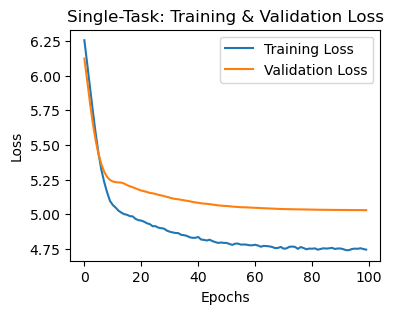

In [14]:
plt.figure(figsize=(4, 3))
plt.plot(train_losses_st, label='Training Loss')
plt.plot(val_losses_st, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Single-Task: Training & Validation Loss')
plt.legend()
plt.show()

#### **Multi-Task Model**

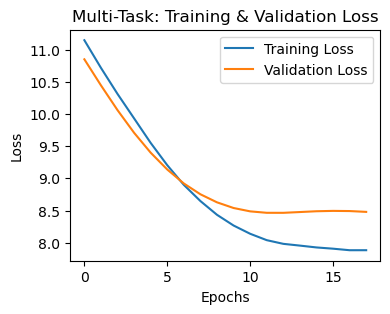

In [15]:
plt.figure(figsize=(4, 3))
plt.plot(train_losses_mt, label='Training Loss')
plt.plot(val_losses_mt, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Multi-Task: Training & Validation Loss')
plt.legend()
plt.show()

## **Run with Test User Input**

#### **Single Task Model**

In [ ]:
input_mod = ["<amt>1 oz</amt>", "<ingred>gin</ingred>"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_mt = model_mt.to(device)

inv_vocab_st = {v: k for k, v in vocab_st.items()}

pad_id = vocab_st["<pad>"]

predict.predict_st(model_st, device, pad_id, vocab_st, inv_vocab_st, input_mod)

#### **Multi Task Model**

In [ ]:
input_mod = [("<amt>1 oz</amt>", "<ingred>gin</ingred>")]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_mt = model_mt.to(device)

inv_vocab_mt_amt = {v: k for k, v in vocab_mt_amt.items()}
inv_vocab_mt_ingred = {v: k for k, v in vocab_mt_ingred.items()}

pad_id_amt = vocab_mt_amt["<pad>"]
pad_id_ingred = vocab_mt_ingred["<pad>"]

predict.predict_mt(
    model_mt, device, pad_id_amt, pad_id_ingred, vocab_mt_amt, vocab_mt_ingred,
    inv_vocab_mt_amt, inv_vocab_mt_ingred, input_mod)


## **Visualize Embeddings**